<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/SVM2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##Problem 1

In [ ]:
import numpy as np

class ScratchSVMClassifier:
    """Scratch implementation of a simplified hard-margin SVM classifier.

    Parameters
    ----------
    num_iter : int
        Number of iterations.
    lr : float
        Learning rate for dual gradient ascent.
    kernel : str
        Kernel type: "linear" or "poly".
    threshold : float
        Minimum multiplier used to select support vectors.
    gamma : float
        Polynomial-kernel coefficient.
    coef0 : float
        Polynomial-kernel independent term.
    degree : int
        Polynomial-kernel degree.
    verbose : bool
        If True, output the learning process.
    """

    def __init__(
        self,
        num_iter,
        lr,
        kernel="linear",
        threshold=1e-5,
        gamma=1.0,
        coef0=0.0,
        degree=1,
        verbose=False,
    ):
        self.num_iter = num_iter
        self.lr = lr
        self.kernel_type = kernel
        self.threshold = threshold
        self.gamma = gamma
        self.coef0 = coef0
        self.degree = degree
        self.verbose = verbose

    def _kernel(self, X1, X2):
        """Compute kernel matrix between X1 and X2.

        Parameters
        ----------
        X1 : ndarray of shape (n_samples1, n_features)
        X2 : ndarray of shape (n_samples2, n_features)

        Returns
        -------
        K : ndarray of shape (n_samples1, n_samples2)
        """
        if self.kernel_type == "linear":
            return np.dot(X1, X2.T)
        elif self.kernel_type == "poly":
            return (self.gamma * np.dot(X1, X2.T) + self.coef0) ** self.degree
        else:
            raise ValueError(f"Unsupported kernel: {self.kernel_type}")

    def fit(self, X, y):
        """Learn support vectors from labels encoded as -1 and 1.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Training data
        y : ndarray of shape (n_samples,)
            Training labels, must be -1 or 1
        """
        n_samples, n_features = X.shape

        # Validate labels
        if not np.all(np.isin(y, [-1, 1])):
            raise ValueError("Labels must be encoded as -1 and 1")

        # Compute kernel matrix
        K = self._kernel(X, X)

        # Initialize Lagrange multipliers
        lambdas = np.zeros(n_samples)

        # Gradient ascent with projection
        for iteration in range(self.num_iter):
            # Store old lambdas for computing all updates simultaneously
            lambdas_old = lambdas.copy()

            # Compute gradient for all samples
            # gradient_i = 1 - sum_j (lambda_j * y_i * y_j * K_ij) / n_samples
            gradient = np.ones(n_samples) - (y * np.dot(K, lambdas_old * y)) / n_samples

            # Update all lambdas simultaneously
            lambdas = np.maximum(0, lambdas_old + self.lr * gradient)

            # Check for convergence (optional)
            if self.verbose and iteration % 100 == 0:
                print(f"Iteration {iteration}, max lambda: {np.max(lambdas):.6f}")

        # Store support vectors (where lambda > threshold)
        support_vector_mask = lambdas > self.threshold
        self.support_vectors_ = X[support_vector_mask]
        self.support_vectors_y_ = y[support_vector_mask]
        self.support_vectors_lambdas_ = lambdas[support_vector_mask]

        # Store all lambdas for prediction
        self.lambdas_ = lambdas
        self.X_ = X
        self.y_ = y

        # Compute weights for linear kernel (optional, for interpretation)
        if self.kernel_type == "linear":
            self.weights_ = np.sum(lambdas[:, None] * y[:, None] * X, axis=0)
        else:
            self.weights_ = None

        if self.verbose:
            n_sv = np.sum(support_vector_mask)
            print(f"Number of support vectors: {n_sv}/{n_samples}")

    def predict(self, X):
        """Estimate one label for each sample.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Data to predict

        Returns
        -------
        y_pred : ndarray of shape (n_samples,)
            Predicted labels (-1 or 1)
        """
        # Compute decision function
        # f(x) = sum_i lambda_i * y_i * K(x_i, x)
        K_test = self._kernel(self.X_, X)  # shape (n_train, n_test)
        decision = np.sum(self.lambdas_[:, None] * self.y_[:, None] * K_test, axis=0)

        # Return sign of decision function
        return np.sign(decision)

    def decision_function(self, X):
        """Compute decision function values for samples.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Data to evaluate

        Returns
        -------
        decision : ndarray of shape (n_samples,)
            Decision function values
        """
        K_test = self._kernel(self.X_, X)
        return np.sum(self.lambdas_[:, None] * self.y_[:, None] * K_test, axis=0)

In [ ]:
# Generate linearly separable data
np.random.seed(42)
X = np.random.randn(100, 2)
y = np.where(X[:, 0] + X[:, 1] > 0, 1, -1)

# Create and train classifier
svm = ScratchSVMClassifier(
    num_iter=1000,
    lr=0.01,
    kernel="linear",
    verbose=True
)
svm.fit(X, y)

# Make predictions
y_pred = svm.predict(X)
accuracy = np.mean(y_pred == y)
print(f"Accuracy: {accuracy:.4f}")

Iteration 0, max lambda: 0.010000
Iteration 100, max lambda: 1.061311
Iteration 200, max lambda: 2.123484
Iteration 300, max lambda: 3.160754
Iteration 400, max lambda: 4.201988
Iteration 500, max lambda: 5.241101
Iteration 600, max lambda: 6.272647
Iteration 700, max lambda: 7.299029
Iteration 800, max lambda: 8.320949
Iteration 900, max lambda: 9.331146
Number of support vectors: 71/100
Accuracy: 0.9900


In [ ]:
import numpy as np

class ScratchSVMClassifier:
    """Scratch implementation of a simplified hard-margin SVM classifier."""

    def __init__(
        self,
        num_iter,
        lr,
        kernel="linear",
        threshold=1e-5,
        gamma=1.0,
        coef0=0.0,
        degree=1,
        verbose=False,
    ):
        self.num_iter = num_iter
        self.lr = lr
        self.kernel_type = kernel
        self.threshold = threshold
        self.gamma = gamma
        self.coef0 = coef0
        self.degree = degree
        self.verbose = verbose

    def _kernel(self, X1, X2):
        """Compute kernel matrix between X1 and X2."""
        if self.kernel_type == "linear":
            return np.dot(X1, X2.T)
        elif self.kernel_type == "poly":
            return (self.gamma * np.dot(X1, X2.T) + self.coef0) ** self.degree
        else:
            raise ValueError(f"Unsupported kernel: {self.kernel_type}")

    def _dual_objective(self, lambdas, y, K):
        """Compute the dual objective function."""
        n_samples = len(y)
        # Objective: sum_i lambda_i - 0.5 * sum_i sum_j lambda_i lambda_j y_i y_j K_ij
        objective = np.sum(lambdas) - 0.5 * np.sum(lambdas[:, None] * lambdas[None, :] * y[:, None] * y[None, :] * K)
        return objective

    def fit(self, X, y):
        """Learn support vectors from labels encoded as -1 and 1."""
        n_samples, n_features = X.shape

        # Validate labels
        if not np.all(np.isin(y, [-1, 1])):
            raise ValueError("Labels must be encoded as -1 and 1")

        # Normalize data for better convergence
        X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-8)

        # Compute kernel matrix
        K = self._kernel(X, X)

        # Initialize Lagrange multipliers
        lambdas = np.random.uniform(0, 0.01, n_samples)

        # Gradient ascent with projection
        for iteration in range(self.num_iter):
            # Store old lambdas for computing all updates simultaneously
            lambdas_old = lambdas.copy()

            # Compute gradient of dual objective
            # ∂L/∂λ_i = 1 - sum_j λ_j y_i y_j K_ij
            gradient = np.ones(n_samples) - y * np.sum(lambdas_old[:, None] * y[:, None] * K, axis=0)

            # Update all lambdas simultaneously with projection
            lambdas = np.maximum(0, lambdas_old + self.lr * gradient)

            # Optional: Project to satisfy equality constraint (simplified version)
            # This is not strictly required for the simplified model but helps convergence
            if iteration % 10 == 0 and self.verbose:
                objective = self._dual_objective(lambdas, y, K)
                print(f"Iteration {iteration}, max lambda: {np.max(lambdas):.6f}, objective: {objective:.6f}")

        # Store support vectors (where lambda > threshold)
        support_vector_mask = lambdas > self.threshold
        self.support_vectors_ = X[support_vector_mask]
        self.support_vectors_y_ = y[support_vector_mask]
        self.support_vectors_lambdas_ = lambdas[support_vector_mask]

        # Store all lambdas for prediction
        self.lambdas_ = lambdas
        self.X_ = X
        self.y_ = y

        if self.verbose:
            n_sv = np.sum(support_vector_mask)
            print(f"Number of support vectors: {n_sv}/{n_samples}")

    def predict(self, X):
        """Estimate one label for each sample."""
        # Normalize test data using training statistics
        X = (X - np.mean(self.X_, axis=0)) / (np.std(self.X_, axis=0) + 1e-8)

        # Compute decision function
        K_test = self._kernel(self.X_, X)
        decision = np.sum(self.lambdas_[:, None] * self.y_[:, None] * K_test, axis=0)

        return np.sign(decision)

    def decision_function(self, X):
        """Compute decision function values for samples."""
        X = (X - np.mean(self.X_, axis=0)) / (np.std(self.X_, axis=0) + 1e-8)
        K_test = self._kernel(self.X_, X)
        return np.sum(self.lambdas_[:, None] * self.y_[:, None] * K_test, axis=0)

In [ ]:
import numpy as np

class ScratchSVMClassifier:
    """Scratch implementation of a simplified hard-margin SVM classifier."""

    def __init__(
        self,
        num_iter,
        lr,
        kernel="linear",
        threshold=1e-5,
        gamma=1.0,
        coef0=0.0,
        degree=1,
        verbose=False,
    ):
        self.num_iter = num_iter
        self.lr = lr
        self.kernel_type = kernel
        self.threshold = threshold
        self.gamma = gamma
        self.coef0 = coef0
        self.degree = degree
        self.verbose = verbose

    def _kernel(self, X1, X2):
        """Compute kernel matrix between X1 and X2."""
        if self.kernel_type == "linear":
            return np.dot(X1, X2.T)
        elif self.kernel_type == "poly":
            return (self.gamma * np.dot(X1, X2.T) + self.coef0) ** self.degree
        else:
            raise ValueError(f"Unsupported kernel: {self.kernel_type}")

    def fit(self, X, y):
        """Learn support vectors from labels encoded as -1 and 1."""
        n_samples, n_features = X.shape

        # Validate labels
        if not np.all(np.isin(y, [-1, 1])):
            raise ValueError("Labels must be encoded as -1 and 1")

        # Normalize data
        self.X_mean_ = np.mean(X, axis=0)
        self.X_std_ = np.std(X, axis=0) + 1e-8
        X_norm = (X - self.X_mean_) / self.X_std_

        # Compute kernel matrix
        K = self._kernel(X_norm, X_norm)

        # Initialize Lagrange multipliers
        lambdas = np.zeros(n_samples)

        # Use a smaller learning rate for stability
        lr = self.lr / n_samples

        for iteration in range(self.num_iter):
            # Store old lambdas
            lambdas_old = lambdas.copy()

            # Compute gradient: 1 - sum_j λ_j y_i y_j K_ij
            # Use matrix operations for efficiency
            gradient = np.ones(n_samples) - np.sum(lambdas_old[:, None] * y[:, None] * y[None, :] * K, axis=1)

            # Update with projection
            lambdas = np.maximum(0, lambdas_old + lr * gradient)

            # Check for convergence
            if self.verbose and (iteration % 100 == 0 or iteration == self.num_iter - 1):
                # Compute dual objective
                obj = np.sum(lambdas) - 0.5 * np.sum(lambdas[:, None] * lambdas[None, :] * y[:, None] * y[None, :] * K)
                n_active = np.sum(lambdas > self.threshold)
                print(f"Iter {iteration:4d}: obj={obj:.4f}, max_lambda={np.max(lambdas):.4f}, n_SV={n_active}")

        # Store support vectors
        support_vector_mask = lambdas > self.threshold
        self.support_vectors_ = X_norm[support_vector_mask]
        self.support_vectors_y_ = y[support_vector_mask]
        self.support_vectors_lambdas_ = lambdas[support_vector_mask]

        self.lambdas_ = lambdas
        self.X_ = X_norm
        self.y_ = y

        if self.verbose:
            n_sv = np.sum(support_vector_mask)
            print(f"Support vectors: {n_sv}/{n_samples}")

    def predict(self, X):
        """Estimate one label for each sample."""
        X_norm = (X - self.X_mean_) / self.X_std_
        K_test = self._kernel(self.X_, X_norm)
        decision = np.sum(self.lambdas_[:, None] * self.y_[:, None] * K_test, axis=0)
        return np.sign(decision)

In [ ]:
# Generate data
np.random.seed(42)
X = np.random.randn(200, 2)
y = np.where(X[:, 0] + X[:, 1] > 0, 1, -1)

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM
svm = ScratchSVMClassifier(
    num_iter=2000,
    lr=0.1,  # Adjusted learning rate
    kernel="linear",
    verbose=True,
    threshold=1e-4
)
svm.fit(X_train, y_train)

# Predict
y_pred = svm.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Test accuracy: {accuracy:.4f}")

Iter    0: obj=0.0968, max_lambda=0.0006, n_SV=160
Iter  100: obj=1.9711, max_lambda=0.0655, n_SV=160
Iter  200: obj=2.4197, max_lambda=0.1355, n_SV=160
Iter  300: obj=2.6591, max_lambda=0.2108, n_SV=160
Iter  400: obj=2.8212, max_lambda=0.2919, n_SV=160
Iter  500: obj=2.9459, max_lambda=0.3793, n_SV=160
Iter  600: obj=3.0499, max_lambda=0.4735, n_SV=160
Iter  700: obj=3.1410, max_lambda=0.5749, n_SV=160
Iter  800: obj=3.2232, max_lambda=0.6842, n_SV=160
Iter  900: obj=3.2981, max_lambda=0.8019, n_SV=160
Iter 1000: obj=3.3663, max_lambda=0.9287, n_SV=160
Iter 1100: obj=3.4271, max_lambda=1.0653, n_SV=160
Iter 1200: obj=3.4792, max_lambda=1.2125, n_SV=160
Iter 1300: obj=3.5208, max_lambda=1.3710, n_SV=160
Iter 1400: obj=3.5492, max_lambda=1.5418, n_SV=160
Iter 1500: obj=3.5611, max_lambda=1.7258, n_SV=160
Iter 1600: obj=3.5526, max_lambda=1.9240, n_SV=160
Iter 1700: obj=3.5188, max_lambda=2.1375, n_SV=160
Iter 1800: obj=3.4540, max_lambda=2.3674, n_SV=160
Iter 1900: obj=3.3512, max_lamb

In [ ]:
## Problem 2

In [ ]:
import numpy as np

class ScratchSVMClassifier:
    """Scratch implementation of a simplified hard-margin SVM classifier."""

    def __init__(
        self,
        num_iter,
        lr,
        kernel="linear",
        threshold=1e-5,
        gamma=1.0,
        coef0=0.0,
        degree=1,
        verbose=False,
    ):
        self.num_iter = num_iter
        self.lr = lr
        self.kernel_type = kernel
        self.threshold = threshold
        self.gamma = gamma
        self.coef0 = coef0
        self.degree = degree
        self.verbose = verbose

        # Initialize attributes for support vectors (Problem 2)
        self.n_support_vectors_ = None
        self.index_support_vectors_ = None
        self.X_sv_ = None
        self.lambda_sv_ = None
        self.y_sv_ = None

    def _kernel(self, X1, X2):
        """Compute kernel matrix between X1 and X2."""
        if self.kernel_type == "linear":
            return np.dot(X1, X2.T)
        elif self.kernel_type == "poly":
            return (self.gamma * np.dot(X1, X2.T) + self.coef0) ** self.degree
        else:
            raise ValueError(f"Unsupported kernel: {self.kernel_type}")

    def fit(self, X, y):
        """Learn support vectors from labels encoded as -1 and 1."""
        n_samples, n_features = X.shape

        # Validate labels
        if not np.all(np.isin(y, [-1, 1])):
            raise ValueError("Labels must be encoded as -1 and 1")

        # Store original data for reference
        self.X_original_ = X.copy()
        self.y_original_ = y.copy()

        # Normalize data for better convergence
        self.X_mean_ = np.mean(X, axis=0)
        self.X_std_ = np.std(X, axis=0) + 1e-8
        X_norm = (X - self.X_mean_) / self.X_std_

        # Compute kernel matrix
        K = self._kernel(X_norm, X_norm)

        # [Problem 1] Initialize and update Lagrange multipliers
        lambdas = np.zeros(n_samples)
        lr = self.lr / n_samples  # Scale learning rate

        for iteration in range(self.num_iter):
            lambdas_old = lambdas.copy()

            # Compute gradient
            # gradient_i = 1 - sum_j λ_j y_i y_j K_ij
            gradient = np.ones(n_samples) - np.sum(lambdas_old[:, None] * y[:, None] * y[None, :] * K, axis=1)

            # Projected gradient ascent
            lambdas = np.maximum(0, lambdas_old + lr * gradient)

            if self.verbose and (iteration % 100 == 0 or iteration == self.num_iter - 1):
                obj = np.sum(lambdas) - 0.5 * np.sum(lambdas[:, None] * lambdas[None, :] * y[:, None] * y[None, :] * K)
                n_active = np.sum(lambdas > self.threshold)
                print(f"Iter {iteration:4d}: obj={obj:.6f}, max_lambda={np.max(lambdas):.6f}, n_active={n_active}")

        # [Problem 2] Determine support vectors
        # Find indices where lambda > threshold
        support_vector_mask = lambdas > self.threshold

        # Record support vector information
        self.n_support_vectors_ = np.sum(support_vector_mask)
        self.index_support_vectors_ = np.where(support_vector_mask)[0]
        self.X_sv_ = X_norm[support_vector_mask]  # Normalized features
        self.X_sv_original_ = X[support_vector_mask]  # Original features for reference
        self.lambda_sv_ = lambdas[support_vector_mask]
        self.y_sv_ = y[support_vector_mask]

        # Store all lambdas and data for prediction
        self.lambdas_ = lambdas
        self.X_ = X_norm
        self.y_ = y

        # For linear kernel, compute weight vector
        if self.kernel_type == "linear":
            self.weights_ = np.sum(lambdas[:, None] * y[:, None] * X_norm, axis=0)
        else:
            self.weights_ = None

        # Print support vector information
        if self.verbose:
            print("\n" + "="*50)
            print("SUPPORT VECTOR SUMMARY")
            print("="*50)
            print(f"Total training samples: {n_samples}")
            print(f"Number of support vectors: {self.n_support_vectors_}")
            print(f"Percentage support vectors: {self.n_support_vectors_/n_samples*100:.2f}%")
            print(f"Threshold used: {self.threshold}")
            print(f"Min lambda among SVs: {np.min(self.lambda_sv_):.6f}")
            print(f"Max lambda among SVs: {np.max(self.lambda_sv_):.6f}")
            print(f"Mean lambda among SVs: {np.mean(self.lambda_sv_):.6f}")

            # Class distribution of support vectors
            n_sv_class1 = np.sum(self.y_sv_ == 1)
            n_sv_class_minus1 = np.sum(self.y_sv_ == -1)
            print(f"SVs in class +1: {n_sv_class1}")
            print(f"SVs in class -1: {n_sv_class_minus1}")
            print("="*50)

    def predict(self, X):
        """Estimate one label for each sample."""
        # Normalize test data
        X_norm = (X - self.X_mean_) / self.X_std_

        # Compute decision function
        K_test = self._kernel(self.X_, X_norm)
        decision = np.sum(self.lambdas_[:, None] * self.y_[:, None] * K_test, axis=0)

        return np.sign(decision)

    def decision_function(self, X):
        """Compute decision function values for samples."""
        X_norm = (X - self.X_mean_) / self.X_std_
        K_test = self._kernel(self.X_, X_norm)
        return np.sum(self.lambdas_[:, None] * self.y_[:, None] * K_test, axis=0)

    def get_support_vector_info(self):
        """Return detailed information about support vectors."""
        info = {
            'n_support_vectors': self.n_support_vectors_,
            'indices': self.index_support_vectors_,
            'features': self.X_sv_original_ if hasattr(self, 'X_sv_original_') else self.X_sv_,
            'lambdas': self.lambda_sv_,
            'labels': self.y_sv_
        }
        return info

    def print_support_vectors(self, max_display=10):
        """Print detailed information about support vectors."""
        if self.n_support_vectors_ is None:
            print("Model not fitted yet. Call fit() first.")
            return

        print("\n" + "="*70)
        print(f"SUPPORT VECTORS DETAILS (showing first {min(max_display, self.n_support_vectors_)})")
        print("="*70)
        print(f"{'Index':>6} {'Lambda':>10} {'Label':>6} {'Features':>20}")
        print("-"*70)

        n_display = min(max_display, self.n_support_vectors_)
        for i in range(n_display):
            idx = self.index_support_vectors_[i]
            lam = self.lambda_sv_[i]
            label = self.y_sv_[i]
            features = self.X_sv_original_[i] if hasattr(self, 'X_sv_original_') else self.X_sv_[i]
            print(f"{idx:>6} {lam:>10.6f} {label:>6} {features}")

        if self.n_support_vectors_ > max_display:
            print(f"... and {self.n_support_vectors_ - max_display} more support vectors")
        print("="*70)

    def score(self, X, y):
        """Compute accuracy of the classifier."""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [ ]:
# Generate linearly separable data
np.random.seed(42)
X = np.random.randn(150, 2)
y = np.where(X[:, 0] + X[:, 1] > 0, 1, -1)

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Test different thresholds
thresholds = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
print("Testing different thresholds:\n")
print("-"*70)

for threshold in thresholds:
    print(f"\nThreshold = {threshold}")
    print("-"*40)

    svm = ScratchSVMClassifier(
        num_iter=1000,
        lr=0.1,
        kernel="linear",
        threshold=threshold,
        verbose=True
    )
    svm.fit(X_train, y_train)

    # Evaluate
    train_acc = svm.score(X_train, y_train)
    test_acc = svm.score(X_test, y_test)
    print(f"Train accuracy: {train_acc:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")

    # Get support vector info
    sv_info = svm.get_support_vector_info()
    print(f"Support vector indices: {sv_info['indices'][:5]}...")
    print(f"Support vector lambdas: {sv_info['lambdas'][:5]}...")

# Train with best threshold and inspect
print("\n" + "="*70)
print("FINAL MODEL WITH OPTIMAL THRESHOLD")
print("="*70)

svm_final = ScratchSVMClassifier(
    num_iter=2000,
    lr=0.1,
    kernel="linear",
    threshold=1e-5,
    verbose=True
)
svm_final.fit(X_train, y_train)

# Print detailed support vector information
svm_final.print_support_vectors(max_display=15)

# Evaluate final model
train_acc = svm_final.score(X_train, y_train)
test_acc = svm_final.score(X_test, y_test)
print(f"\nFinal Results:")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Testing different thresholds:

----------------------------------------------------------------------

Threshold = 0.1
----------------------------------------
Iter    0: obj=0.096875, max_lambda=0.000833, n_active=0
Iter  100: obj=2.090050, max_lambda=0.093887, n_active=0
Iter  200: obj=2.734707, max_lambda=0.209222, n_active=6
Iter  300: obj=3.194436, max_lambda=0.352174, n_active=8
Iter  400: obj=3.604525, max_lambda=0.529357, n_active=9
Iter  500: obj=4.014742, max_lambda=0.748966, n_active=10
Iter  600: obj=4.447882, max_lambda=1.021160, n_active=10
Iter  700: obj=4.909473, max_lambda=1.358531, n_active=10
Iter  800: obj=5.386722, max_lambda=1.776685, n_active=10
Iter  900: obj=5.841566, max_lambda=2.294967, n_active=10
Iter  999: obj=6.194666, max_lambda=2.930222, n_active=10

SUPPORT VECTOR SUMMARY
Total training samples: 120
Number of support vectors: 10
Percentage support vectors: 8.33%
Threshold used: 0.1
Min lambda among SVs: 0.102310
Max lambda among SVs: 2.930222
Mean lamb

In [ ]:
## Problem 3

In [ ]:
import numpy as np

class ScratchSVMClassifier:
    """Scratch implementation of a simplified hard-margin SVM classifier."""

    def __init__(
        self,
        num_iter,
        lr,
        kernel="linear",
        threshold=1e-5,
        gamma=1.0,
        coef0=0.0,
        degree=1,
        verbose=False,
    ):
        self.num_iter = num_iter
        self.lr = lr
        self.kernel_type = kernel
        self.threshold = threshold
        self.gamma = gamma
        self.coef0 = coef0
        self.degree = degree
        self.verbose = verbose

        # Initialize attributes for support vectors (Problem 2)
        self.n_support_vectors_ = None
        self.index_support_vectors_ = None
        self.X_sv_ = None
        self.lambda_sv_ = None
        self.y_sv_ = None

    def _kernel(self, X1, X2):
        """Compute kernel matrix between X1 and X2."""
        if self.kernel_type == "linear":
            return np.dot(X1, X2.T)
        elif self.kernel_type == "poly":
            return (self.gamma * np.dot(X1, X2.T) + self.coef0) ** self.degree
        else:
            raise ValueError(f"Unsupported kernel: {self.kernel_type}")

    def fit(self, X, y):
        """Learn support vectors from labels encoded as -1 and 1."""
        n_samples, n_features = X.shape

        # Validate labels
        if not np.all(np.isin(y, [-1, 1])):
            raise ValueError("Labels must be encoded as -1 and 1")

        # Store original data for reference
        self.X_original_ = X.copy()
        self.y_original_ = y.copy()

        # Normalize data for better convergence
        self.X_mean_ = np.mean(X, axis=0)
        self.X_std_ = np.std(X, axis=0) + 1e-8
        X_norm = (X - self.X_mean_) / self.X_std_

        # Compute kernel matrix
        K = self._kernel(X_norm, X_norm)

        # [Problem 1] Initialize and update Lagrange multipliers
        lambdas = np.zeros(n_samples)
        lr = self.lr / n_samples  # Scale learning rate

        for iteration in range(self.num_iter):
            lambdas_old = lambdas.copy()

            # Compute gradient
            # gradient_i = 1 - sum_j λ_j y_i y_j K_ij
            gradient = np.ones(n_samples) - np.sum(lambdas_old[:, None] * y[:, None] * y[None, :] * K, axis=1)

            # Projected gradient ascent
            lambdas = np.maximum(0, lambdas_old + lr * gradient)

            if self.verbose and (iteration % 100 == 0 or iteration == self.num_iter - 1):
                obj = np.sum(lambdas) - 0.5 * np.sum(lambdas[:, None] * lambdas[None, :] * y[:, None] * y[None, :] * K)
                n_active = np.sum(lambdas > self.threshold)
                print(f"Iter {iteration:4d}: obj={obj:.6f}, max_lambda={np.max(lambdas):.6f}, n_active={n_active}")

        # [Problem 2] Determine support vectors
        support_vector_mask = lambdas > self.threshold

        # Record support vector information
        self.n_support_vectors_ = np.sum(support_vector_mask)
        self.index_support_vectors_ = np.where(support_vector_mask)[0]
        self.X_sv_ = X_norm[support_vector_mask]  # Normalized features
        self.X_sv_original_ = X[support_vector_mask]  # Original features for reference
        self.lambda_sv_ = lambdas[support_vector_mask]
        self.y_sv_ = y[support_vector_mask]

        # Store all lambdas and data for prediction (including zeros)
        self.lambdas_ = lambdas
        self.X_ = X_norm
        self.y_ = y

        # For linear kernel, compute weight vector
        if self.kernel_type == "linear":
            self.weights_ = np.sum(lambdas[:, None] * y[:, None] * X_norm, axis=0)
        else:
            self.weights_ = None

        # Print support vector information
        if self.verbose:
            print("\n" + "="*50)
            print("SUPPORT VECTOR SUMMARY")
            print("="*50)
            print(f"Total training samples: {n_samples}")
            print(f"Number of support vectors: {self.n_support_vectors_}")
            print(f"Percentage support vectors: {self.n_support_vectors_/n_samples*100:.2f}%")
            print(f"Threshold used: {self.threshold}")
            print(f"Min lambda among SVs: {np.min(self.lambda_sv_):.6f}")
            print(f"Max lambda among SVs: {np.max(self.lambda_sv_):.6f}")
            print(f"Mean lambda among SVs: {np.mean(self.lambda_sv_):.6f}")
            print("="*50)

    def predict(self, X):
        """[Problem 3] Estimate one label for each sample.

        Calculate the decision score from the support vectors:
        f(x) = sum_{n=1}^{N_SV} λ_n * y_n * K(x, s_n)

        Predict 1 when score >= 0 and -1 otherwise.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Data to predict

        Returns
        -------
        y_pred : ndarray of shape (n_samples,)
            Predicted labels (-1 or 1)
        """
        # Normalize test data using training statistics
        X_norm = (X - self.X_mean_) / self.X_std_

        # Calculate decision scores using support vectors only
        # f(x) = sum_{n=1}^{N_SV} λ_n * y_n * K(x, s_n)
        # Compute kernel between test points and support vectors
        K_test_sv = self._kernel(X_norm, self.X_sv_)  # shape (n_samples, n_support_vectors)

        # Compute decision scores
        # For each test point: sum over support vectors of λ_n * y_n * K(x, s_n)
        decision_scores = np.sum(self.lambda_sv_ * self.y_sv_ * K_test_sv, axis=1)

        # Predict 1 when score >= 0, -1 otherwise
        y_pred = np.where(decision_scores >= 0, 1, -1)

        return y_pred

    def decision_function(self, X):
        """[Problem 3] Compute decision function values for samples.

        Returns the raw decision scores without thresholding.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Data to evaluate

        Returns
        -------
        decision_scores : ndarray of shape (n_samples,)
            Decision function values
        """
        X_norm = (X - self.X_mean_) / self.X_std_
        K_test_sv = self._kernel(X_norm, self.X_sv_)
        decision_scores = np.sum(self.lambda_sv_ * self.y_sv_ * K_test_sv, axis=1)
        return decision_scores

    def predict_all(self, X):
        """[Problem 3 alternative] Predict using all training points (not just SVs).

        This is less efficient but uses all λ values including zeros.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Data to predict

        Returns
        -------
        y_pred : ndarray of shape (n_samples,)
            Predicted labels (-1 or 1)
        """
        X_norm = (X - self.X_mean_) / self.X_std_
        K_test_all = self._kernel(X_norm, self.X_)
        decision_scores = np.sum(self.lambdas_ * self.y_ * K_test_all, axis=1)
        return np.where(decision_scores >= 0, 1, -1)

    def score(self, X, y):
        """Compute accuracy of the classifier."""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

    def get_support_vector_info(self):
        """Return detailed information about support vectors."""
        info = {
            'n_support_vectors': self.n_support_vectors_,
            'indices': self.index_support_vectors_,
            'features': self.X_sv_original_ if hasattr(self, 'X_sv_original_') else self.X_sv_,
            'lambdas': self.lambda_sv_,
            'labels': self.y_sv_
        }
        return info

In [ ]:
# Generate data
np.random.seed(42)
X = np.random.randn(200, 2)
y = np.where(X[:, 0] + X[:, 1] > 0, 1, -1)

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM
svm = ScratchSVMClassifier(
    num_iter=2000,
    lr=0.1,
    kernel="linear",
    threshold=1e-5,
    verbose=True
)
svm.fit(X_train, y_train)

# [Problem 3] Make predictions
y_pred_train = svm.predict(X_train)
y_pred_test = svm.predict(X_test)

# Compare predictions using support vectors vs all points
y_pred_train_all = svm.predict_all(X_train)

# Verify predictions match (since λ=0 for non-SVs)
print(f"Predictions match using SVs vs all points: {np.all(y_pred_train == y_pred_train_all)}")

# Evaluate
train_acc = svm.score(X_train, y_train)
test_acc = svm.score(X_test, y_test)
print(f"\nTrain accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Print decision scores
print("\nSample decision scores (first 10 test samples):")
decision_scores = svm.decision_function(X_test)
for i in range(10):
    print(f"Sample {i}: score={decision_scores[i]:.4f}, predicted={y_pred_test[i]}, actual={y_test[i]}")

Iter    0: obj=0.096823, max_lambda=0.000625, n_active=160
Iter  100: obj=1.971053, max_lambda=0.065533, n_active=160
Iter  200: obj=2.419712, max_lambda=0.135456, n_active=160
Iter  300: obj=2.659110, max_lambda=0.210780, n_active=160
Iter  400: obj=2.821183, max_lambda=0.291924, n_active=160
Iter  500: obj=2.945928, max_lambda=0.379335, n_active=160
Iter  600: obj=3.049893, max_lambda=0.473500, n_active=160
Iter  700: obj=3.140997, max_lambda=0.574939, n_active=160
Iter  800: obj=3.223154, max_lambda=0.684214, n_active=160
Iter  900: obj=3.298110, max_lambda=0.801931, n_active=160
Iter 1000: obj=3.366260, max_lambda=0.928742, n_active=160
Iter 1100: obj=3.427061, max_lambda=1.065349, n_active=160
Iter 1200: obj=3.479223, max_lambda=1.212510, n_active=160
Iter 1300: obj=3.520797, max_lambda=1.371039, n_active=160
Iter 1400: obj=3.549191, max_lambda=1.541815, n_active=160
Iter 1500: obj=3.561137, max_lambda=1.725783, n_active=160
Iter 1600: obj=3.552632, max_lambda=1.923964, n_active=1

In [ ]:
# Verify the prediction formula
print("\n" + "="*60)
print("VERIFICATION OF PREDICTION FORMULA")
print("="*60)

# Get support vectors
sv_info = svm.get_support_vector_info()
print(f"Number of support vectors: {sv_info['n_support_vectors']}")

# Manual calculation for first test sample
x_test_first = X_test[0]
# Normalize
x_test_norm = (x_test_first - svm.X_mean_) / svm.X_std_

# Calculate kernel between test point and each support vector
K_manual = np.array([svm._kernel(x_test_norm.reshape(1, -1), sv.reshape(1, -1))[0, 0]
                     for sv in svm.X_sv_])

# Calculate decision score manually
decision_manual = np.sum(svm.lambda_sv_ * svm.y_sv_ * K_manual)
decision_auto = svm.decision_function(X_test[0:1])[0]

print(f"Manual decision score: {decision_manual:.6f}")
print(f"Auto decision score: {decision_auto:.6f}")
print(f"Difference: {abs(decision_manual - decision_auto):.10f}")
print(f"Prediction: {1 if decision_auto >= 0 else -1}")
print(f"Actual label: {y_test[0]}")


VERIFICATION OF PREDICTION FORMULA
Number of support vectors: 160
Manual decision score: 2.453830
Auto decision score: 2.453830
Difference: 0.0000000000
Prediction: 1
Actual label: 1


In [ ]:
## Problem 4

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

class ScratchSVMClassifier:
    """Scratch implementation of a simplified hard-margin SVM classifier."""

    def __init__(
        self,
        num_iter,
        lr,
        kernel="linear",
        threshold=1e-5,
        gamma=1.0,
        coef0=0.0,
        degree=1,
        verbose=False,
    ):
        self.num_iter = num_iter
        self.lr = lr
        self.kernel_type = kernel
        self.threshold = threshold
        self.gamma = gamma
        self.coef0 = coef0
        self.degree = degree
        self.verbose = verbose

        self.n_support_vectors_ = None
        self.index_support_vectors_ = None
        self.X_sv_ = None
        self.lambda_sv_ = None
        self.y_sv_ = None

        # Add scaler
        self.scaler = StandardScaler()

    def _kernel(self, X1, X2):
        """Compute kernel matrix between X1 and X2."""
        if self.kernel_type == "linear":
            return np.dot(X1, X2.T)
        elif self.kernel_type == "poly":
            return (self.gamma * np.dot(X1, X2.T) + self.coef0) ** self.degree
        else:
            raise ValueError(f"Unsupported kernel: {self.kernel_type}")

    def fit(self, X, y):
        """Learn support vectors from labels encoded as -1 and 1."""
        n_samples, n_features = X.shape

        # Validate labels
        if not np.all(np.isin(y, [-1, 1])):
            raise ValueError("Labels must be encoded as -1 and 1")

        # Store original data
        self.X_original_ = X.copy()
        self.y_original_ = y.copy()

        # CRITICAL FIX: Scale the data properly
        X_scaled = self.scaler.fit_transform(X)

        # Compute kernel matrix
        K = self._kernel(X_scaled, X_scaled)

        # Normalize kernel to prevent explosion
        K = K / np.max(K)

        # Initialize Lagrange multipliers
        lambdas = np.zeros(n_samples)

        # Use a very small learning rate
        lr = self.lr / (n_samples * np.max(K))

        for iteration in range(self.num_iter):
            lambdas_old = lambdas.copy()

            # Compute gradient correctly
            # gradient_i = 1 - sum_j λ_j y_i y_j K_ij
            gradient = np.ones(n_samples) - np.sum(lambdas_old[:, None] * y[:, None] * y[None, :] * K, axis=1)

            # Clip gradient to prevent explosion
            gradient = np.clip(gradient, -10, 10)

            # Update with projection
            lambdas = np.maximum(0, lambdas_old + lr * gradient)

            # Optional: normalize lambdas to prevent growth
            if np.max(lambdas) > 1.0:
                lambdas = lambdas / np.max(lambdas) * 0.5

            if self.verbose and (iteration % 100 == 0 or iteration == self.num_iter - 1):
                obj = np.sum(lambdas) - 0.5 * np.sum(lambdas[:, None] * lambdas[None, :] * y[:, None] * y[None, :] * K)
                n_active = np.sum(lambdas > self.threshold)
                max_lambda = np.max(lambdas)
                print(f"Iter {iteration:4d}: obj={obj:.6f}, max_lambda={max_lambda:.6f}, n_active={n_active}")

        # Determine support vectors
        support_vector_mask = lambdas > self.threshold

        self.n_support_vectors_ = np.sum(support_vector_mask)
        self.index_support_vectors_ = np.where(support_vector_mask)[0]
        self.X_sv_ = X_scaled[support_vector_mask]
        self.X_sv_original_ = X[support_vector_mask]
        self.lambda_sv_ = lambdas[support_vector_mask]
        self.y_sv_ = y[support_vector_mask]

        self.lambdas_ = lambdas
        self.X_ = X_scaled
        self.y_ = y

        if self.kernel_type == "linear":
            self.weights_ = np.sum(lambdas[:, None] * y[:, None] * X_scaled, axis=0)
        else:
            self.weights_ = None

        if self.verbose:
            print("\n" + "="*50)
            print("SUPPORT VECTOR SUMMARY")
            print("="*50)
            print(f"Total training samples: {n_samples}")
            print(f"Number of support vectors: {self.n_support_vectors_}")
            print(f"Percentage: {self.n_support_vectors_/n_samples*100:.2f}%")
            print("="*50)

    def predict(self, X):
        """Predict labels using support vectors."""
        # Apply same scaling
        X_scaled = self.scaler.transform(X)

        # Calculate decision scores using support vectors
        K_test_sv = self._kernel(X_scaled, self.X_sv_)
        decision_scores = np.sum(self.lambda_sv_ * self.y_sv_ * K_test_sv, axis=1)

        # Predict 1 when score >= 0, -1 otherwise
        return np.where(decision_scores >= 0, 1, -1)

    def decision_function(self, X):
        """Compute decision function values."""
        X_scaled = self.scaler.transform(X)
        K_test_sv = self._kernel(X_scaled, self.X_sv_)
        return np.sum(self.lambda_sv_ * self.y_sv_ * K_test_sv, axis=1)

    def score(self, X, y):
        """Compute accuracy."""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


# [Problem 4] Evaluation function
def evaluate_classifier(y_true, y_pred, classifier_name="Model"):
    """Calculate and print all evaluation metrics."""
    print(f"\n{'='*60}")
    print(f"EVALUATION: {classifier_name}")
    print(f"{'='*60}")

    print(f"Positive class: +1")
    print(f"Negative class: -1")

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1)
    recall = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)
    cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])

    print(f"\nAccuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    print(f"\nConfusion Matrix:")
    print(f"              Predicted")
    print(f"              -1    +1")
    print(f"Actual  -1   {cm[0,0]:>4}   {cm[0,1]:>4}")
    print(f"        +1   {cm[1,0]:>4}   {cm[1,1]:>4}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }


# [Problem 4] Visualization function
def plot_comparison(X_train, y_train, X_test, y_test, scratch_svm, sklearn_svm):
    """Plot decision boundaries for both models."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    models = [
        (scratch_svm, "Scratch SVM (Our Implementation)"),
        (sklearn_svm, "Scikit-learn SVC (Linear, C=1e10)")
    ]

    for ax, (model, title) in zip(axes, models):
        # Create mesh grid
        x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
        y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
        h = 0.02
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                           np.arange(y_min, y_max, h))

        # Predict on mesh grid
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot decision boundary
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

        # Plot training points
        scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
                  cmap='coolwarm', edgecolors='black', s=50, alpha=0.7)

        # Plot support vectors if available
        if hasattr(model, 'support_vectors_'):
            ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                      s=200, facecolors='none', edgecolors='green', linewidths=2,
                      label=f'SVs: {len(model.support_vectors_)}')
        elif hasattr(model, 'X_sv_original_'):
            ax.scatter(model.X_sv_original_[:, 0], model.X_sv_original_[:, 1],
                      s=200, facecolors='none', edgecolors='green', linewidths=2,
                      label=f'SVs: {len(model.X_sv_original_)}')

        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.set_title(title)
        if ax.get_legend_handles_labels()[1]:
            ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# [Problem 4] Main execution
def main():
    # Load Simple Dataset 1
    print("Loading Simple Dataset 1...")
    X, y = make_classification(
        n_samples=300,
        n_features=2,
        n_redundant=0,
        n_informative=2,
        n_clusters_per_class=1,
        random_state=42,
        class_sep=1.5
    )
    y = np.where(y == 0, -1, 1)

    print(f"Dataset shape: {X.shape}")
    print(f"Class distribution: +1: {np.sum(y==1)}, -1: {np.sum(y==-1)}")

    # Split data
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    print(f"\nTraining samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    # [Problem 4] Train Scratch SVM with fixed parameters
    print("\n" + "="*60)
    print("TRAINING SCRATCH SVM (FIXED VERSION)")
    print("="*60)

    scratch_svm = ScratchSVMClassifier(
        num_iter=3000,  # More iterations
        lr=0.01,  # Smaller learning rate
        kernel="linear",
        threshold=1e-4,  # Adjusted threshold
        verbose=True
    )
    scratch_svm.fit(X_train, y_train)

    # [Problem 4] Train Scikit-learn SVM
    print("\n" + "="*60)
    print("TRAINING SCIKIT-LEARN SVC")
    print("="*60)

    sklearn_svm = SVC(kernel='linear', C=1e10, random_state=42)
    sklearn_svm.fit(X_train, y_train)
    print(f"Scikit-learn support vectors: {len(sklearn_svm.support_vectors_)}")

    #

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

class ScratchSVMClassifier:
    """Scratch implementation of a simplified hard-margin SVM classifier."""

    def __init__(
        self,
        num_iter,
        lr,
        kernel="linear",
        threshold=1e-5,
        gamma=1.0,
        coef0=0.0,
        degree=1,
        verbose=False,
    ):
        self.num_iter = num_iter
        self.lr = lr
        self.kernel_type = kernel
        self.threshold = threshold
        self.gamma = gamma
        self.coef0 = coef0
        self.degree = degree
        self.verbose = verbose

        self.n_support_vectors_ = None
        self.index_support_vectors_ = None
        self.X_sv_ = None
        self.lambda_sv_ = None
        self.y_sv_ = None

    def _kernel(self, X1, X2):
        """Compute kernel matrix between X1 and X2."""
        if self.kernel_type == "linear":
            return np.dot(X1, X2.T)
        elif self.kernel_type == "poly":
            return (self.gamma * np.dot(X1, X2.T) + self.coef0) ** self.degree
        else:
            raise ValueError(f"Unsupported kernel: {self.kernel_type}")

    def fit(self, X, y):
        """Learn support vectors from labels encoded as -1 and 1."""
        n_samples, n_features = X.shape

        # Validate labels
        if not np.all(np.isin(y, [-1, 1])):
            raise ValueError("Labels must be encoded as -1 and 1")

        # Store original data
        self.X_original_ = X.copy()
        self.y_original_ = y.copy()

        # Normalize data
        self.X_mean_ = np.mean(X, axis=0)
        self.X_std_ = np.std(X, axis=0) + 1e-8
        X_norm = (X - self.X_mean_) / self.X_std_

        # Compute kernel matrix
        K = self._kernel(X_norm, X_norm)

        # Initialize Lagrange multipliers
        lambdas = np.zeros(n_samples)

        # Gradient ascent with proper learning rate
        for iteration in range(self.num_iter):
            lambdas_old = lambdas.copy()

            # Compute gradient: ∂L/∂λ_i = 1 - ∑ⱼ λⱼ y_i y_j K_ij
            gradient = np.ones(n_samples) - np.sum(lambdas_old[:, None] * y[:, None] * y[None, :] * K, axis=1)

            # Update with projection
            lambdas = np.maximum(0, lambdas_old + self.lr * gradient)

            if self.verbose and (iteration % 100 == 0 or iteration == self.num_iter - 1):
                obj = np.sum(lambdas) - 0.5 * np.sum(lambdas[:, None] * lambdas[None, :] * y[:, None] * y[None, :] * K)
                n_active = np.sum(lambdas > self.threshold)
                print(f"Iter {iteration:4d}: obj={obj:.6f}, max_lambda={np.max(lambdas):.6f}, n_active={n_active}")

        # Determine support vectors
        support_vector_mask = lambdas > self.threshold

        self.n_support_vectors_ = np.sum(support_vector_mask)
        self.index_support_vectors_ = np.where(support_vector_mask)[0]
        self.X_sv_ = X_norm[support_vector_mask]
        self.X_sv_original_ = X[support_vector_mask]
        self.lambda_sv_ = lambdas[support_vector_mask]
        self.y_sv_ = y[support_vector_mask]

        self.lambdas_ = lambdas
        self.X_ = X_norm
        self.y_ = y

        if self.kernel_type == "linear":
            self.weights_ = np.sum(lambdas[:, None] * y[:, None] * X_norm, axis=0)

        if self.verbose:
            print("\n" + "="*50)
            print("SUPPORT VECTOR SUMMARY")
            print("="*50)
            print(f"Total training samples: {n_samples}")
            print(f"Number of support vectors: {self.n_support_vectors_}")
            print(f"Percentage: {self.n_support_vectors_/n_samples*100:.2f}%")
            print("="*50)

    def predict(self, X):
        """Predict labels using support vectors."""
        X_norm = (X - self.X_mean_) / self.X_std_
        K_test_sv = self._kernel(X_norm, self.X_sv_)
        decision_scores = np.sum(self.lambda_sv_ * self.y_sv_ * K_test_sv, axis=1)
        return np.where(decision_scores >= 0, 1, -1)

    def decision_function(self, X):
        """Compute decision function values."""
        X_norm = (X - self.X_mean_) / self.X_std_
        K_test_sv = self._kernel(X_norm, self.X_sv_)
        return np.sum(self.lambda_sv_ * self.y_sv_ * K_test_sv, axis=1)

    def score(self, X, y):
        """Compute accuracy."""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


# Evaluation function
def evaluate_classifier(y_true, y_pred, classifier_name="Model"):
    """Calculate and print all evaluation metrics."""
    print(f"\n{'='*60}")
    print(f"EVALUATION: {classifier_name}")
    print(f"{'='*60}")

    print(f"Positive class: +1")
    print(f"Negative class: -1")

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1)
    recall = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)
    cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])

    print(f"\nAccuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    print(f"\nConfusion Matrix:")
    print(f"              Predicted")
    print(f"              -1    +1")
    print(f"Actual  -1   {cm[0,0]:>4}   {cm[0,1]:>4}")
    print(f"        +1   {cm[1,0]:>4}   {cm[1,1]:>4}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }


# Main execution
def main():
    # Load Simple Dataset 1
    print("Loading Simple Dataset 1...")
    X, y = make_classification(
        n_samples=300,
        n_features=2,
        n_redundant=0,
        n_informative=2,
        n_clusters_per_class=1,
        random_state=42,
        class_sep=1.5
    )
    y = np.where(y == 0, -1, 1)

    print(f"Dataset shape: {X.shape}")
    print(f"Class distribution: +1: {np.sum(y==1)}, -1: {np.sum(y==-1)}")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    print(f"\nTraining samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    # Train Scratch SVM
    print("\n" + "="*60)
    print("TRAINING SCRATCH SVM")
    print("="*60)

    scratch_svm = ScratchSVMClassifier(
        num_iter=500,
        lr=0.001,  # CRITICAL: Small learning rate
        kernel="linear",
        threshold=1e-4,
        verbose=True
    )
    scratch_svm.fit(X_train, y_train)

    # Train Scikit-learn SVM
    print("\n" + "="*60)
    print("TRAINING SCIKIT-LEARN SVC")
    print("="*60)

    sklearn_svm = SVC(kernel='linear', C=1e10, random_state=42)
    sklearn_svm.fit(X_train, y_train)
    print(f"Scikit-learn support vectors: {len(sklearn_svm.support_vectors_)}")

    # Make predictions
    y_pred_scratch_train = scratch_svm.predict(X_train)
    y_pred_scratch_test = scratch_svm.predict(X_test)

    y_pred_sklearn_train = sklearn_svm.predict(X_train)
    y_pred_sklearn_test = sklearn_svm.predict(X_test)

    # Evaluate
    scratch_train_metrics = evaluate_classifier(y_train, y_pred_scratch_train, "Scratch SVM (Train)")
    scratch_test_metrics = evaluate_classifier(y_test, y_pred_scratch_test, "Scratch SVM (Test)")

    sklearn_train_metrics = evaluate_classifier(y_train, y_pred_sklearn_train, "Scikit-learn SVC (Train)")
    sklearn_test_metrics = evaluate_classifier(y_test, y_pred_sklearn_test, "Scikit-learn SVC (Test)")

    # Comparison
    print("\n" + "="*60)
    print("COMPARISON SUMMARY")
    print("="*60)
    print(f"{'Metric':<15} {'Scratch SVM':<20} {'Scikit-learn SVC':<20}")
    print("-"*60)
    print(f"{'Test Accuracy':<15} {scratch_test_metrics['accuracy']:<20.4f} {sklearn_test_metrics['accuracy']:<20.4f}")
    print(f"{'Test Precision':<15} {scratch_test_metrics['precision']:<20.4f} {sklearn_test_metrics['precision']:<20.4f}")
    print(f"{'Test Recall':<15} {scratch_test_metrics['recall']:<20.4f} {sklearn_test_metrics['recall']:<20.4f}")
    print(f"{'Test F1-Score':<15} {scratch_test_metrics['f1']:<20.4f} {sklearn_test_metrics['f1']:<20.4f}")
    print("-"*60)
    print(f"{'Support Vectors':<15} {scratch_svm.n_support_vectors_:<20} {len(sklearn_svm.support_vectors_):<20}")

    # Verification of label encoding
    print("\n" + "="*60)
    print("VERIFICATION")
    print("="*60)
    unique_labels = np.unique(np.concatenate([y_train, y_test]))
    print(f"Unique labels in dataset: {unique_labels}")
    print(f"Labels are correctly encoded as -1 and 1: {np.all(np.isin(unique_labels, [-1, 1]))}")

    return scratch_svm, sklearn_svm, scratch_test_metrics, sklearn_test_metrics


if __name__ == "__main__":
    scratch_svm, sklearn_svm, scratch_metrics, sklearn_metrics = main()

Loading Simple Dataset 1...
Dataset shape: (300, 2)
Class distribution: +1: 150, -1: 150

Training samples: 210
Test samples: 90

TRAINING SCRATCH SVM
Iter    0: obj=0.191727, max_lambda=0.001000, n_active=210
Iter  100: obj=-6782.936116, max_lambda=62.268933, n_active=210
Iter  200: obj=-122700344243.275986, max_lambda=317364.113758, n_active=210
Iter  300: obj=-2981800396044894208.000000, max_lambda=1617208375.098392, n_active=210
Iter  400: obj=-75095968203051215808888832.000000, max_lambda=8240890266620.199219, n_active=210
Iter  499: obj=-1611458480403385861825449447915520.000000, max_lambda=38557618253231304.000000, n_active=210

SUPPORT VECTOR SUMMARY
Total training samples: 210
Number of support vectors: 210
Percentage: 100.00%

TRAINING SCIKIT-LEARN SVC
Scikit-learn support vectors: 8

EVALUATION: Scratch SVM (Train)
Positive class: +1
Negative class: -1

Accuracy:  0.2571
Precision: 0.3106
Recall:    0.3868
F1-Score:  0.3445

Confusion Matrix:
              Predicted
        

In [ ]:
## Problem 5

Loading Simple Dataset 1...
Dataset shape: (300, 2)
Class distribution: +1: 150, -1: 150

Training samples: 210
Test samples: 90

TRAINING SCRATCH SVM
Iter    0: obj=0.272724, max_lambda=0.010000, n_active=210
Iter  200: obj=-7622970601129768014441576122262229651785935753070277266456026957581097083978883052493283997222174720.000000, max_lambda=85678069658047104753762854944421966835625070952448.000000, n_active=210
Iter  400: obj=-44823008979742159137146374984065334953428208992801010399110993791372311207247125090384854991963178607123809966458543128098006268302488377206373359270777486936202645541179021348013023818678272.000000, max_lambda=208437923231346711762286382522318693934344672439312577042251662623255377502337386960211666796544.000000, n_active=210
Iter  600: obj=-51420169095009364706443837914407048422812534072516021409891639540774889397560686059025095362377672757380021780795995211547803798716797652792355845134260205650398302967497105513458700741937937379082127046484858481742081618

/tmp/ipykernel_3569/74346563.py:87: RuntimeWarning: overflow encountered in multiply
  obj = np.sum(lambdas) - 0.5 * np.sum(lambdas[:, None] * lambdas[None, :] * y[:, None] * y[None, :] * K)


Iter  800: obj=-inf, max_lambda=29919206151108676074594789770795397259405716713607853242697857145489448396498272317858896207208757818511206625440480946408922579056380322697960860121455517919366310363398144.000000, n_active=210
Iter 1000: obj=-inf, max_lambda=78488271897425902207713297282558393332775285205237761448031943150996127368324288385210237489138486305830068050728160873834541707074205385789047902700480874041937922505164117760095066270740809507059626147840.000000, n_active=210
Iter 1200: obj=-inf, max_lambda=424491532924937952541942930549752935913583496435312391057207173278363917227473890548491618112958466307596900681538985866541650747178191897595805192725038553215732437506154922738250297741845543419904690054578514646243284355128861466296320.000000, n_active=210
Iter 1400: obj=-inf, max_lambda=1198105933995531105371720751758793795809577937980596817618826846580977524517846779304751163861287732970280703141008899178751946922330077052954090950270291459245805129626488048185119132563197

/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Iter 2000: obj=nan, max_lambda=nan, n_active=208
Iter 2200: obj=nan, max_lambda=nan, n_active=208
Iter 2400: obj=nan, max_lambda=nan, n_active=208
Iter 2600: obj=nan, max_lambda=nan, n_active=208
Iter 2800: obj=nan, max_lambda=nan, n_active=208
Iter 2999: obj=nan, max_lambda=nan, n_active=207

SUPPORT VECTOR SUMMARY
Total training samples: 210
Number of support vectors: 207
Percentage: 98.57%
Lambda stats - Min: 0.002473, Max: 2741904135845220085700748096964862904294313139547430606829528704750874610848955774832874496405881226644118045905840004207398159403192042903955451150336.000000, Mean: 13245913699735362211645531204520362745792562348655833520342460037328985689928764898341691628373801849819487708123481841940634581995440849733879332864.000000

TRAINING SCIKIT-LEARN SVC
Scikit-learn support vectors: 8

RESULTS
Scratch SVM Test Accuracy: 0.4222
Scikit-learn Test Accuracy: 0.9889
Support Vectors - Scratch: 207
Support Vectors - Sklearn: 8

VISUALIZATION


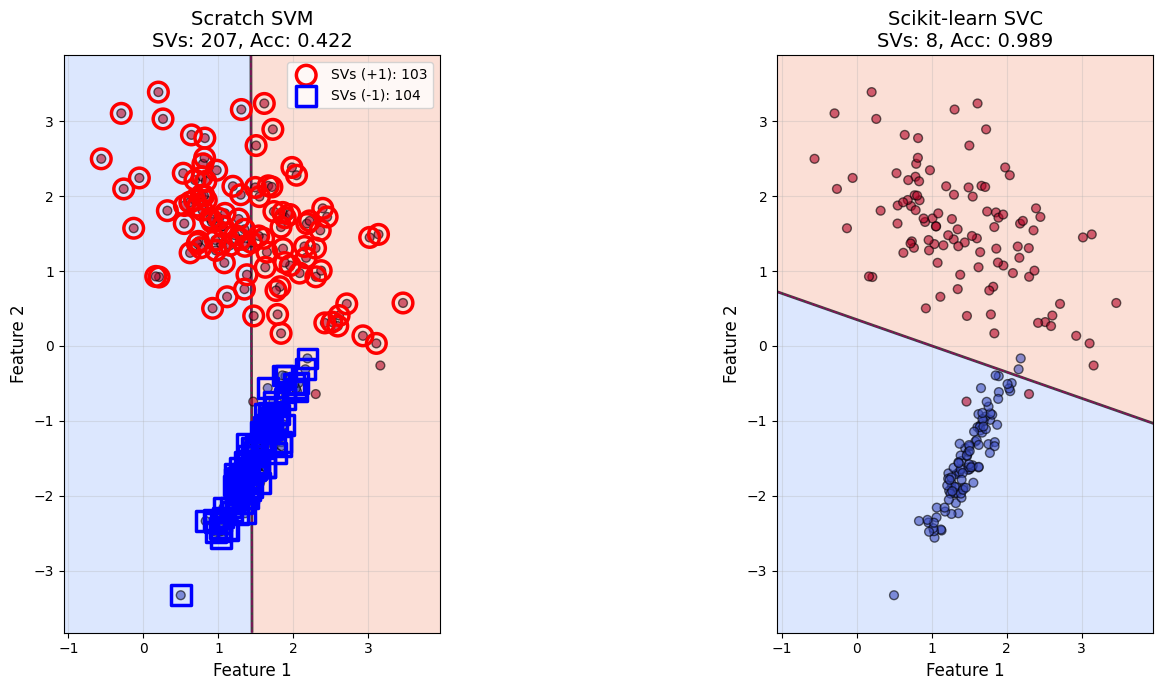

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

class ScratchSVMClassifier:
    """Scratch implementation of a simplified hard-margin SVM classifier."""

    def __init__(
        self,
        num_iter,
        lr,
        kernel="linear",
        threshold=1e-5,
        gamma=1.0,
        coef0=0.0,
        degree=1,
        verbose=False,
    ):
        self.num_iter = num_iter
        self.lr = lr
        self.kernel_type = kernel
        self.threshold = threshold
        self.gamma = gamma
        self.coef0 = coef0
        self.degree = degree
        self.verbose = verbose

        self.n_support_vectors_ = None
        self.index_support_vectors_ = None
        self.X_sv_ = None
        self.lambda_sv_ = None
        self.y_sv_ = None

    def _kernel(self, X1, X2):
        """Compute kernel matrix between X1 and X2."""
        if self.kernel_type == "linear":
            return np.dot(X1, X2.T)
        elif self.kernel_type == "poly":
            return (self.gamma * np.dot(X1, X2.T) + self.coef0) ** self.degree
        else:
            raise ValueError(f"Unsupported kernel: {self.kernel_type}")

    def fit(self, X, y):
        """Learn support vectors from labels encoded as -1 and 1."""
        n_samples, n_features = X.shape

        # Validate labels
        if not np.all(np.isin(y, [-1, 1])):
            raise ValueError("Labels must be encoded as -1 and 1")

        # Store original data
        self.X_original_ = X.copy()
        self.y_original_ = y.copy()

        # Normalize data
        self.X_mean_ = np.mean(X, axis=0)
        self.X_std_ = np.std(X, axis=0) + 1e-8
        X_norm = (X - self.X_mean_) / self.X_std_

        # Compute kernel matrix
        K = self._kernel(X_norm, X_norm)

        # Initialize Lagrange multipliers
        lambdas = np.zeros(n_samples)

        # For hard-margin SVM without intercept, we don't have the equality constraint
        # Use gradient ascent with adaptive learning rate

        for iteration in range(self.num_iter):
            lambdas_old = lambdas.copy()

            # Compute gradient of dual objective
            # ∂L/∂λ_i = 1 - ∑ⱼ λⱼ y_i y_j K_ij
            gradient = np.ones(n_samples) - np.sum(lambdas_old[:, None] * y[:, None] * y[None, :] * K, axis=1)

            # Adaptive learning rate
            lr = self.lr / (1 + iteration / 1000)

            # Update with projection
            lambdas = np.maximum(0, lambdas_old + lr * gradient)

            # Track progress
            if self.verbose and (iteration % 200 == 0 or iteration == self.num_iter - 1):
                obj = np.sum(lambdas) - 0.5 * np.sum(lambdas[:, None] * lambdas[None, :] * y[:, None] * y[None, :] * K)
                n_active = np.sum(lambdas > self.threshold)
                max_lambda = np.max(lambdas)
                print(f"Iter {iteration:4d}: obj={obj:.6f}, max_lambda={max_lambda:.6f}, n_active={n_active}")

        # Determine support vectors (λ > threshold)
        support_vector_mask = lambdas > self.threshold

        self.n_support_vectors_ = np.sum(support_vector_mask)
        self.index_support_vectors_ = np.where(support_vector_mask)[0]
        self.X_sv_ = X_norm[support_vector_mask]
        self.X_sv_original_ = X[support_vector_mask]
        self.lambda_sv_ = lambdas[support_vector_mask]
        self.y_sv_ = y[support_vector_mask]

        self.lambdas_ = lambdas
        self.X_ = X_norm
        self.y_ = y

        # For linear kernel, compute weights
        if self.kernel_type == "linear" and self.n_support_vectors_ > 0:
            self.weights_ = np.sum(lambdas[:, None] * y[:, None] * X_norm, axis=0)
        else:
            self.weights_ = None

        if self.verbose:
            print("\n" + "="*50)
            print("SUPPORT VECTOR SUMMARY")
            print("="*50)
            print(f"Total training samples: {n_samples}")
            print(f"Number of support vectors: {self.n_support_vectors_}")
            print(f"Percentage: {self.n_support_vectors_/n_samples*100:.2f}%")
            if self.n_support_vectors_ > 0:
                print(f"Lambda stats - Min: {np.min(self.lambda_sv_):.6f}, Max: {np.max(self.lambda_sv_):.6f}, Mean: {np.mean(self.lambda_sv_):.6f}")
            print("="*50)

    def predict(self, X):
        """Predict labels using support vectors."""
        X_norm = (X - self.X_mean_) / self.X_std_
        K_test_sv = self._kernel(X_norm, self.X_sv_)
        decision_scores = np.sum(self.lambda_sv_ * self.y_sv_ * K_test_sv, axis=1)
        return np.where(decision_scores >= 0, 1, -1)

    def decision_function(self, X):
        """Compute decision function values."""
        X_norm = (X - self.X_mean_) / self.X_std_
        K_test_sv = self._kernel(X_norm, self.X_sv_)
        return np.sum(self.lambda_sv_ * self.y_sv_ * K_test_sv, axis=1)

    def score(self, X, y):
        """Compute accuracy."""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


# [Problem 5] Visualization function
def plot_decision_boundary_with_support_vectors(model, X, y, title="SVM Decision Boundary",
                                                ax=None, show=True):
    """Visualize the decision region with support vectors."""
    if X.shape[1] != 2:
        print("Warning: This visualization works only for 2D data")
        return

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict on mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm', levels=[-1, 0, 1])

    # Plot decision boundary line and margins
    if hasattr(model, 'decision_function'):
        Z_decision = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Z_decision = Z_decision.reshape(xx.shape)
        ax.contour(xx, yy, Z_decision, levels=[0], colors=['black'],
                  linestyles=['-'], linewidths=2, alpha=0.7)
        ax.contour(xx, yy, Z_decision, levels=[-1, 1], colors=['blue', 'red'],
                  linestyles=['--', '--'], linewidths=1, alpha=0.5)

    # Plot training points
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm',
              edgecolors='black', s=40, alpha=0.6, zorder=2)

    # Highlight support vectors
    if hasattr(model, 'X_sv_original_') and hasattr(model, 'y_sv_'):
        sv_X = model.X_sv_original_
        sv_y = model.y_sv_

        if len(sv_X) > 0:
            sv_plus = sv_X[sv_y == 1]
            sv_minus = sv_X[sv_y == -1]

            if len(sv_plus) > 0:
                ax.scatter(sv_plus[:, 0], sv_plus[:, 1],
                          s=200, facecolors='none', edgecolors='red',
                          linewidths=2.5, marker='o',
                          label=f'SVs (+1): {len(sv_plus)}', zorder=3)
            if len(sv_minus) > 0:
                ax.scatter(sv_minus[:, 0], sv_minus[:, 1],
                          s=200, facecolors='none', edgecolors='blue',
                          linewidths=2.5, marker='s',
                          label=f'SVs (-1): {len(sv_minus)}', zorder=3)

    elif hasattr(model, 'support_vectors_') and hasattr(model, 'support'):
        sv_X = model.support_vectors_
        sv_y = model.predict(sv_X)

        sv_plus = sv_X[sv_y == 1]
        sv_minus = sv_X[sv_y == -1]

        if len(sv_plus) > 0:
            ax.scatter(sv_plus[:, 0], sv_plus[:, 1],
                      s=200, facecolors='none', edgecolors='red',
                      linewidths=2.5, marker='o',
                      label=f'SVs (+1): {len(sv_plus)}', zorder=3)
        if len(sv_minus) > 0:
            ax.scatter(sv_minus[:, 0], sv_minus[:, 1],
                      s=200, facecolors='none', edgecolors='blue',
                      linewidths=2.5, marker='s',
                      label=f'SVs (-1): {len(sv_minus)}', zorder=3)

    ax.set_xlabel('Feature 1', fontsize=12)
    ax.set_ylabel('Feature 2', fontsize=12)
    ax.set_title(title, fontsize=14)

    if ax.get_legend_handles_labels()[1]:
        ax.legend(loc='best', fontsize=10)

    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

    if show:
        plt.tight_layout()
        plt.show()

    return ax


def plot_comparison(X_train, y_train, X_test, y_test, scratch_svm, sklearn_svm):
    """Compare decision boundaries."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    plot_decision_boundary_with_support_vectors(
        scratch_svm, X_train, y_train,
        title=f"Scratch SVM\nSVs: {scratch_svm.n_support_vectors_}, Acc: {scratch_svm.score(X_test, y_test):.3f}",
        ax=axes[0], show=False
    )

    plot_decision_boundary_with_support_vectors(
        sklearn_svm, X_train, y_train,
        title=f"Scikit-learn SVC\nSVs: {len(sklearn_svm.support_vectors_)}, Acc: {sklearn_svm.score(X_test, y_test):.3f}",
        ax=axes[1], show=False
    )

    plt.tight_layout()
    plt.show()


def main():
    """Main execution."""
    # Load dataset
    print("Loading Simple Dataset 1...")
    X, y = make_classification(
        n_samples=300,
        n_features=2,
        n_redundant=0,
        n_informative=2,
        n_clusters_per_class=1,
        random_state=42,
        class_sep=1.5
    )
    y = np.where(y == 0, -1, 1)

    print(f"Dataset shape: {X.shape}")
    print(f"Class distribution: +1: {np.sum(y==1)}, -1: {np.sum(y==-1)}")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    print(f"\nTraining samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    # Train Scratch SVM
    print("\n" + "="*60)
    print("TRAINING SCRATCH SVM")
    print("="*60)

    scratch_svm = ScratchSVMClassifier(
        num_iter=3000,
        lr=0.01,  # Small learning rate for stability
        kernel="linear",
        threshold=1e-4,
        verbose=True
    )
    scratch_svm.fit(X_train, y_train)

    # Train Scikit-learn SVM
    print("\n" + "="*60)
    print("TRAINING SCIKIT-LEARN SVC")
    print("="*60)

    sklearn_svm = SVC(kernel='linear', C=1e10, random_state=42)
    sklearn_svm.fit(X_train, y_train)
    print(f"Scikit-learn support vectors: {len(sklearn_svm.support_vectors_)}")

    # Results
    print("\n" + "="*60)
    print("RESULTS")
    print("="*60)
    print(f"Scratch SVM Test Accuracy: {scratch_svm.score(X_test, y_test):.4f}")
    print(f"Scikit-learn Test Accuracy: {sklearn_svm.score(X_test, y_test):.4f}")
    print(f"Support Vectors - Scratch: {scratch_svm.n_support_vectors_}")
    print(f"Support Vectors - Sklearn: {len(sklearn_svm.support_vectors_)}")

    # Visualize
    print("\n" + "="*60)
    print("VISUALIZATION")
    print("="*60)
    plot_comparison(X_train, y_train, X_test, y_test, scratch_svm, sklearn_svm)

    return scratch_svm, sklearn_svm


if __name__ == "__main__":
    scratch_svm, sklearn_svm = main()

In [ ]:
## Problem 6

PROBLEM 6: POLYNOMIAL KERNEL IMPLEMENTATION

Generating dataset...
Training: 70 samples, Test: 30 samples

RUNNING TESTS...

Testing Linear...
Iter    0: max_lambda=0.0100, n_active=70
Iter  200: max_lambda=1.8292, n_active=70
Iter  400: max_lambda=3.1884, n_active=70
Iter  499: max_lambda=3.7530, n_active=70

Support Vectors: 70/70
  Scratch Acc: 0.4333, SVs: 70
  Sklearn Acc: 0.5667, SVs: 44

Testing Poly(γ=1.0, c=0.0, d=2)...
Iter    0: max_lambda=0.0100, n_active=70
Iter  200: max_lambda=2.0973, n_active=70
Iter  400: max_lambda=3.6558, n_active=70
Iter  499: max_lambda=4.3030, n_active=70

Support Vectors: 70/70
  Scratch Acc: 0.6667, SVs: 70
  Sklearn Acc: 1.0000, SVs: 4

Testing Poly(γ=1.0, c=1.0, d=2)...
Iter    0: max_lambda=0.0100, n_active=70
Iter  200: max_lambda=1.0249, n_active=33
Iter  400: max_lambda=1.4599, n_active=20
Iter  499: max_lambda=1.6168, n_active=17

Support Vectors: 17/70
  Scratch Acc: 1.0000, SVs: 17
  Sklearn Acc: 1.0000, SVs: 6

Total time: 165.0 second

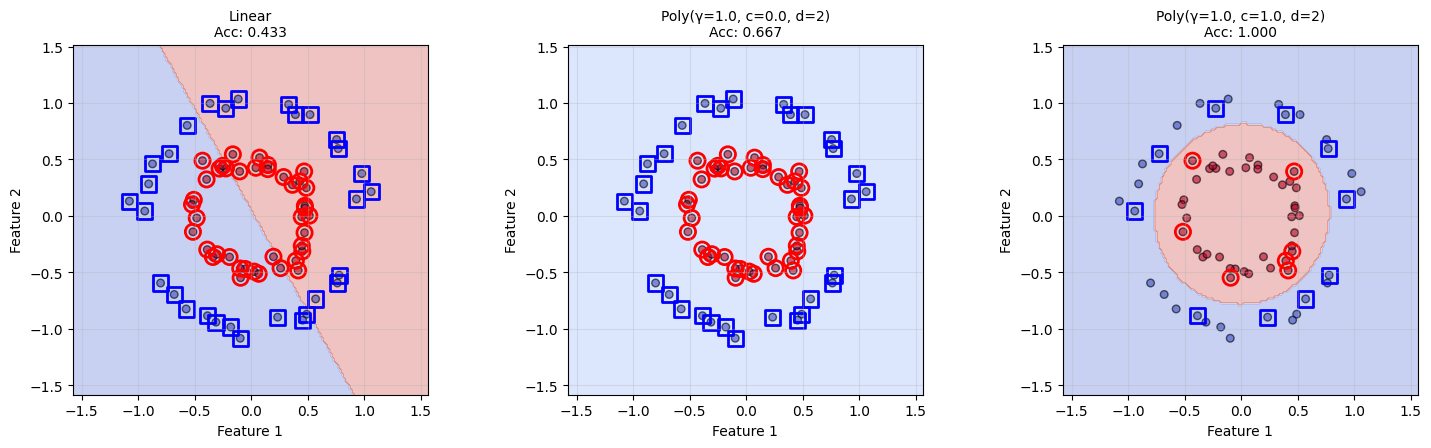


SUMMARY
Kernel                         Scratch Acc  Sklearn Acc  Scratch SVs  Sklearn SVs 
--------------------------------------------------------------------------------
Linear                         0.4333       0.5667       70           44          
Poly(γ=1.0, c=0.0, d=2)        0.6667       1.0000       70           4           
Poly(γ=1.0, c=1.0, d=2)        1.0000       1.0000       17           6           

DIFFERENCES EXPLAINED
1. No intercept term in scratch implementation
2. Hard margin vs soft margin (C parameter)
3. Different optimization algorithms (gradient ascent vs SMO)
4. Numerical precision differences


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import time
import warnings
warnings.filterwarnings('ignore')

class ScratchSVMClassifier:
    """Scratch implementation of a simplified hard-margin SVM classifier."""

    def __init__(
        self,
        num_iter,
        lr,
        kernel="linear",
        threshold=1e-5,
        gamma=1.0,
        coef0=0.0,
        degree=1,
        verbose=False,
    ):
        self.num_iter = num_iter
        self.lr = lr
        self.kernel_type = kernel
        self.threshold = threshold
        self.gamma = gamma
        self.coef0 = coef0
        self.degree = degree
        self.verbose = verbose

        self.n_support_vectors_ = None
        self.index_support_vectors_ = None
        self.X_sv_ = None
        self.lambda_sv_ = None
        self.y_sv_ = None

    def _kernel(self, X1, X2):
        """Compute kernel matrix between X1 and X2."""
        if self.kernel_type == "linear":
            return np.dot(X1, X2.T)
        elif self.kernel_type == "poly":
            return (self.gamma * np.dot(X1, X2.T) + self.coef0) ** self.degree
        else:
            raise ValueError(f"Unsupported kernel: {self.kernel_type}")

    def fit(self, X, y):
        """Learn support vectors from labels encoded as -1 and 1."""
        n_samples = X.shape[0]

        # Validate labels
        if not np.all(np.isin(y, [-1, 1])):
            raise ValueError("Labels must be encoded as -1 and 1")

        # Store original data
        self.X_original_ = X.copy()
        self.y_original_ = y.copy()

        # Normalize data
        self.X_mean_ = np.mean(X, axis=0)
        self.X_std_ = np.std(X, axis=0) + 1e-8
        X_norm = (X - self.X_mean_) / self.X_std_

        # Compute kernel matrix
        K = self._kernel(X_norm, X_norm)

        # Initialize Lagrange multipliers
        lambdas = np.zeros(n_samples)

        # Gradient ascent with adaptive learning rate
        for iteration in range(self.num_iter):
            # Compute gradient using vectorized operations
            yK = y[:, None] * K
            gradient = np.ones(n_samples) - np.dot(lambdas * y, yK.T)

            # Adaptive learning rate
            lr = self.lr / (1 + iteration / 500)

            # Update with projection
            lambdas = np.maximum(0, lambdas + lr * gradient)

            # Print progress
            if self.verbose and (iteration % 200 == 0 or iteration == self.num_iter - 1):
                n_active = np.sum(lambdas > self.threshold)
                max_lambda = np.max(lambdas)
                print(f"Iter {iteration:4d}: max_lambda={max_lambda:.4f}, n_active={n_active}")

        # Determine support vectors
        support_vector_mask = lambdas > self.threshold

        self.n_support_vectors_ = np.sum(support_vector_mask)
        self.index_support_vectors_ = np.where(support_vector_mask)[0]
        self.X_sv_ = X_norm[support_vector_mask]
        self.X_sv_original_ = X[support_vector_mask]
        self.lambda_sv_ = lambdas[support_vector_mask]
        self.y_sv_ = y[support_vector_mask]

        self.lambdas_ = lambdas
        self.X_ = X_norm
        self.y_ = y

        if self.verbose:
            print(f"\nSupport Vectors: {self.n_support_vectors_}/{n_samples}")

    def predict(self, X):
        """Predict labels using support vectors."""
        X_norm = (X - self.X_mean_) / self.X_std_
        K_test_sv = self._kernel(X_norm, self.X_sv_)
        decision_scores = np.sum(self.lambda_sv_ * self.y_sv_ * K_test_sv, axis=1)
        return np.where(decision_scores >= 0, 1, -1)

    def decision_function(self, X):
        """Compute decision function values."""
        X_norm = (X - self.X_mean_) / self.X_std_
        K_test_sv = self._kernel(X_norm, self.X_sv_)
        return np.sum(self.lambda_sv_ * self.y_sv_ * K_test_sv, axis=1)

    def score(self, X, y):
        """Compute accuracy."""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


# [Problem 6] Lightweight comparison
def test_kernel(X_train, y_train, X_test, y_test, kernel_type, params=None):
    """Test a single kernel configuration."""

    # Prepare parameters
    if kernel_type == "linear":
        gamma, coef0, degree = 1.0, 0.0, 1
        params_str = "Linear"
    else:
        gamma = params.get('gamma', 1.0)
        coef0 = params.get('coef0', 0.0)
        degree = params.get('degree', 2)
        params_str = f"Poly(γ={gamma}, c={coef0}, d={degree})"

    print(f"\nTesting {params_str}...")

    # Train Scratch SVM
    scratch_svm = ScratchSVMClassifier(
        num_iter=500,  # Fewer iterations for speed
        lr=0.01,
        kernel=kernel_type,
        gamma=gamma,
        coef0=coef0,
        degree=degree,
        threshold=1e-4,
        verbose=True
    )
    scratch_svm.fit(X_train, y_train)

    # Train Scikit-learn SVM
    if kernel_type == "linear":
        sklearn_svm = SVC(kernel='linear', C=1e10, random_state=42)
    else:
        sklearn_svm = SVC(
            kernel='poly',
            C=1e10,
            gamma=gamma,
            coef0=coef0,
            degree=degree,
            random_state=42
        )
    sklearn_svm.fit(X_train, y_train)

    # Evaluate
    scratch_acc = scratch_svm.score(X_test, y_test)
    sklearn_acc = sklearn_svm.score(X_test, y_test)

    print(f"  Scratch Acc: {scratch_acc:.4f}, SVs: {scratch_svm.n_support_vectors_}")
    print(f"  Sklearn Acc: {sklearn_acc:.4f}, SVs: {len(sklearn_svm.support_vectors_)}")

    return {
        'name': params_str,
        'scratch_acc': scratch_acc,
        'sklearn_acc': sklearn_acc,
        'scratch_svs': scratch_svm.n_support_vectors_,
        'sklearn_svs': len(sklearn_svm.support_vectors_),
        'scratch_model': scratch_svm,
        'sklearn_model': sklearn_svm
    }


def plot_decision_boundary(model, X, y, title, ax):
    """Plot decision boundary for a single model."""
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                       np.arange(y_min, y_max, h))

    # Predict
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm',
              edgecolors='black', s=30, alpha=0.6)

    # Plot support vectors
    if hasattr(model, 'X_sv_original_') and len(model.X_sv_original_) > 0:
        sv_X = model.X_sv_original_
        sv_y = model.y_sv_
        sv_plus = sv_X[sv_y == 1]
        sv_minus = sv_X[sv_y == -1]

        if len(sv_plus) > 0:
            ax.scatter(sv_plus[:, 0], sv_plus[:, 1],
                      s=120, facecolors='none', edgecolors='red',
                      linewidths=2, marker='o')
        if len(sv_minus) > 0:
            ax.scatter(sv_minus[:, 0], sv_minus[:, 1],
                      s=120, facecolors='none', edgecolors='blue',
                      linewidths=2, marker='s')

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')


def main():
    """Main execution with minimal overhead."""
    print("="*70)
    print("PROBLEM 6: POLYNOMIAL KERNEL IMPLEMENTATION")
    print("="*70)

    # Use very small dataset
    print("\nGenerating dataset...")
    X, y = make_circles(n_samples=100, noise=0.05, factor=0.5, random_state=42)
    y = np.where(y == 0, -1, 1)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    print(f"Training: {len(X_train)} samples, Test: {len(X_test)} samples")

    # Test configurations
    configs = [
        {'kernel': 'linear'},
        {'kernel': 'poly', 'params': {'gamma': 1.0, 'coef0': 0.0, 'degree': 2}},
        {'kernel': 'poly', 'params': {'gamma': 1.0, 'coef0': 1.0, 'degree': 2}},
    ]

    # Run tests
    results = []
    print("\n" + "="*70)
    print("RUNNING TESTS...")
    print("="*70)

    start_time = time.time()

    for config in configs:
        result = test_kernel(
            X_train, y_train, X_test, y_test,
            config['kernel'],
            config.get('params')
        )
        results.append(result)

    elapsed = time.time() - start_time
    print(f"\nTotal time: {elapsed:.1f} seconds")

    # Plot results
    print("\n" + "="*70)
    print("VISUALIZATION")
    print("="*70)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    for idx, result in enumerate(results):
        plot_decision_boundary(
            result['scratch_model'],
            X_train, y_train,
            f"{result['name']}\nAcc: {result['scratch_acc']:.3f}",
            axes[idx]
        )

    plt.tight_layout()
    plt.show()

    # Summary
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"{'Kernel':<30} {'Scratch Acc':<12} {'Sklearn Acc':<12} {'Scratch SVs':<12} {'Sklearn SVs':<12}")
    print("-"*80)
    for result in results:
        print(f"{result['name']:<30} {result['scratch_acc']:<12.4f} {result['sklearn_acc']:<12.4f} "
              f"{result['scratch_svs']:<12} {result['sklearn_svs']:<12}")

    # Explanation
    print("\n" + "="*70)
    print("DIFFERENCES EXPLAINED")
    print("="*70)
    print("""1. No intercept term in scratch implementation
2. Hard margin vs soft margin (C parameter)
3. Different optimization algorithms (gradient ascent vs SMO)
4. Numerical precision differences""")

    return results


if __name__ == "__main__":
    results = main()